# DE9IM Class Tests

[DE-9IM](https://en.wikipedia.org/wiki/DE-9IM)


## Setup

### Imports

In [ ]:
# Shared Packages
import shapely

# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from relations import *

In [2]:
%matplotlib inline

The DE-9IM model is based on a 3×3 intersection matrix with the form:

![DE-9IM Matrix](<../../Images/DE9IM equations.png>)

where 
_dim_ is the dimension of the intersection (∩) of the interior (I), boundary (B), and exterior (E) of geometries a and b.

Visually, for two overlapping polygonal geometries, the result of the function DE_9IM(a,b) looks like:


![DE_9IM Example](../../Images/DE-9IM.png)

This matrix can be serialized. Reading from left-to-right and top-to-bottom, the result is

![DE9IM Linearized](<../../Images/linearized matrix.png>)

 So, in a compact representation as string code is '212101212'.


The relationship string is converted to binary format, where 'F'
is '0' and '1' or '2' is '1'.

Args:
    poly_a (shapely.MultiPolygon): All contours for a structure on
        a single slice.
    poly_b (shapely.MultiPolygon): All contours for a second
        structure on the same slice.
    relation_str (str): The DE-9IM relationship string for the two

Attributes:
    str (str): A length 9 string of the DE-9IM relationship consisting of
        'F', '1', or '2'.
    relation (str): The relationship string converted to binary format,
        where 'F' becomes '0', and '1' or '2' becomes '1'.

Methods:
    to_int (shift=0): Returns the relationship string converted to an
        integer.  The shift argument shifts the binary equivalent the
        given number of places to the left.

In [3]:
box6 = shapely.MultiPolygon([shapely.Polygon(box_points(6))])
box6
box4 = shapely.MultiPolygon([shapely.Polygon(box_points(4))])
r = DE9IM(box6, box4)
r

<DE9IM>: 212FF1FF2

In [4]:
r.int

457

In [5]:
print(str(r))

|111|
|001|
|001|


In [6]:
b = r.boundary_adjustment('a')
print(str(b))
b

|000|
|100|
|000|


<DE9IM>: FFF2FFFFF

In [7]:
b = r.boundary_adjustment('b')
print(str(b))
b

|010|
|000|
|000|


<DE9IM>: F2FFFFFFF

In [8]:
b = r.transpose()
print(str(b))
b

|100|
|100|
|111|


<DE9IM>: 2FF1FF212

In [9]:
box6 = shapely.MultiPolygon([shapely.Polygon(box_points(6))])
box4 = shapely.MultiPolygon([shapely.Polygon(box_points(4))])
relation = DE9IM(box4, box6)
boundary_relation = relation.boundary_adjustment('b')
print(boundary_relation)
boundary_relation

|010|
|000|
|000|


<DE9IM>: F2FFFFFFF

## Tests

### Disjoint

- Disjoint cannot be distinguished from Shelters and Surrounds using only
  the Region relationship. 
  - The Exterior relationship is required to identify Surrounds.
  - The Exterior and Hull relationships are required to identify Shelters.


<link rel="stylesheet" href="relations.css">
<table><tr><td>
<table  style="border: none;">
<tr class="l"  style="border: none;">
<th style="border: none;">Disjoint</th>
<th width=100 rowspan=2 style="border: none;">
<img src="../../Images/Relationships/disjoint.png" alt="Disjoint">
</th></tr>
<tr style="border: none;"><td class="d" style="border: none;">
<span class="a">a</span> and <span class="b">b</span> have no points in common.
</td></tr></table>
</td><td>
<table class="f">
<tr><th>Matrix</th>
<td><table class="matrix">        
    <tr><td>F</td><td>F</td><td>*</td></tr>
    <tr><td>F</td><td>F</td><td>*</td></tr>
    <tr><td>*</td><td>*</td><td>*</td></tr>
    </table>
    </td>
</tr>
</tr><tr class="bin">
<th>Mask</th><td><span>110110000</span></td></tr>
<tr class="bin">
<th>Value</th><td><span>000000000</span></td></tr>
</table>
</tr></tr></table>

In [ ]:
mask =  0b110110000
value = 0b000000000

def disjoint_example():
    circle4_left = shapely.Polygon(circle_points(4, offset_x=-4.5))
    circle4_right = shapely.Polygon(circle_points(4, offset_x=4.5))
    return circle4_left, circle4_right
a, b = disjoint_example()
ax = plot_ab(a, b)


r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

### Borders and Confines

- Borders and Confines cannot be distinguished from the region relationship alone.
  - The Exterior relationship is require to identify Confines.

<link rel="stylesheet" href="relations.css">
<table><tr><td>
<table  style="border: none;">
<tr class="l"  style="border: none;">
<th style="border: none;">Borders and Confines</th>
<th width=100 rowspan=2 style="border: none;">
<img src="../../Images/Relationships/borders.png" alt="Borders"><br>
<img src="../../Images/Relationships/confines.png" alt="Confines">
</th></tr>
<tr style="border: none;"><td class="d" style="border: none;">
The boundaries of 
<span class="a">a</span> and <span class="b">b</span> 
have more than one point in common, but their interiors do not intersect.
</td></tr></table>
</td><td>
<table class="f">
<tr><th>Matrix</th>
<td><table class="matrix">        
    <tr><td>F</td><td>*</td><td>*</td></tr>
    <tr><td>*</td><td>1</td><td>*</td></tr>
    <tr><td>*</td><td>*</td><td>*</td></tr>
    </table>
    </td>
</tr>
</tr><tr class="bin">
<th>Mask</th><td><span>100010000</span></td></tr>
<tr class="bin">
<th>Value</th><td><span>000010000</span></td></tr>
</table>
</tr></tr></table>

#### Exterior Borders

In [13]:
mask =  0b100010000
value = 0b000010000


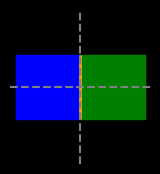

|001|
|011|
|111|


True

In [14]:
def simple_box_borders_example():
    box4_left = shapely.Polygon(box_points(4, offset_x=-2))
    box4_right = shapely.Polygon(box_points(4, offset_x=2))
    return box4_left, box4_right

a, b = simple_box_borders_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

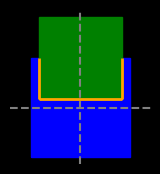

|001|
|011|
|111|


True

In [15]:
def inserted_borders_example():
    box6 = shapely.Polygon(box_points(6))
    box5_up = shapely.Polygon(box_points(5, offset_y=3))
    box6_cropped = shapely.difference(box6, box5_up)
    return box6_cropped, box5_up

a, b = inserted_borders_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

#### Interior Borders (Confines)

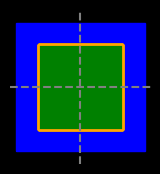

|001|
|011|
|101|


True

In [16]:
def simple_confines_example():
    # 6 cm x 6 cm box with 4cm x 4 cm hole
    box6 = shapely.Polygon(box_points(6))
    box4 = shapely.Polygon(box_points(4))
    a = box6 - box4
    return a, box4

a, b = simple_confines_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

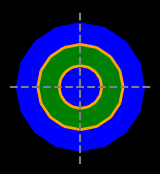

|001|
|011|
|101|


True

In [17]:
def confines_ring_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle2 = shapely.Polygon(circle_points(1))
    # b has internal borders with the ring portion of a, but has an external
    # border with the island part of a. The internal borders relation wins.
    a = (circle6 - circle4).union(circle2)
    b = circle4 - circle2
    return a, b

a, b = confines_ring_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

### Overlaps

<link rel="stylesheet" href="relations.css">
<table><tr><td>
<table  style="border: none;">
<tr class="l"  style="border: none;">
<th style="border: none;">Overlaps</th>
<th width=100 rowspan=2 style="border: none;">
<img src="../../Images/Relationships/overlaps simple.png" alt="Overlaps">
</th></tr>
<tr style="border: none;"><td class="d" style="border: none;">
<span class="a">a</span> and <span class="b">b</span> 
have some but not all points in common.
</td></tr></table>
</td><td>
<table class="f">
<tr><th>Matrix</th>
<td><table class="matrix">        
    <tr><td>2</td><td>*</td><td>*</td></tr>
    <tr><td>1</td><td>*</td><td>*</td></tr>
    <tr><td>*</td><td>*</td><td>*</td></tr>
    </table>
    </td>
</tr>
</tr><tr class="bin">
<th>Mask</th><td><span>100100000</span></td></tr>
<tr class="bin">
<th>Value</th><td><span>100100000</span></td></tr>
</table>
</tr></tr></table>

In [20]:
mask =  0b100100000
value = 0b100100000


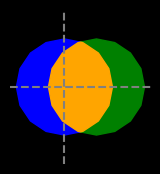

|111|
|101|
|111|


True

In [21]:
def overlaps_simple_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle6_offset = shapely.Polygon(circle_points(3, offset_x=2))
    return circle6, circle6_offset

a, b = overlaps_simple_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

- In Theory the relation matrix should have all values as `True` (1):

|R|E|H|
|-|-|-|
|1|1|1|
|1|***1***|1|
|1|1|1|

but it is missing the central value, due to rounding errors.

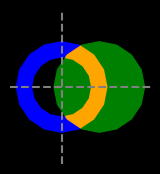

|111|
|101|
|111|


True

In [22]:
def overlaps_ring_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle6_offset = shapely.Polygon(circle_points(3, offset_x=2.5))
    a = circle6 - circle4
    return a, circle6_offset

a, b = overlaps_ring_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

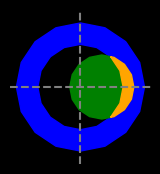

|111|
|101|
|111|


True

In [23]:
def overlaps_surrounded_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle2 = shapely.Polygon(circle_points(1.5, offset_x=1))
    a = circle6 - circle4
    return a, circle2

a, b = overlaps_surrounded_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

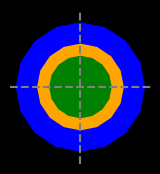

|111|
|101|
|101|


True

In [24]:
def overlaps_ring_surrounded_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle3 = shapely.Polygon(circle_points(1.5))
    circle4 = shapely.Polygon(circle_points(2))
    a = circle6 - circle3
    return a, circle4

a, b = overlaps_ring_surrounded_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

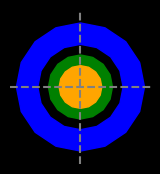

|101|
|101|
|111|


True

In [25]:
def overlaps_island_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle2 = shapely.Polygon(circle_points(1))
    circle3 = shapely.Polygon(circle_points(1.5))
    a = (circle6 - circle4).union(circle2)
    return a, circle3

a, b = overlaps_island_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

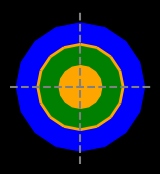

|101|
|111|
|101|


True

In [26]:
def overlaps_archipelago_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle2 = shapely.Polygon(circle_points(1))
    a = (circle6 - circle4).union(circle2)
    return a, circle4

a, b = overlaps_archipelago_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

### Inverted Overlap

<link rel="stylesheet" href="relations.css">
- Because we expect that <span class="a">a</span> will always be larger than <span class="b">b</span>, we can expect that the relation below will never be encountered.
<table class="matrix">        
    <tr><td>2</td><td>1</td><td>2</td></tr>
    <tr><td>F</td><td>*</td><td>*</td></tr>
    <tr><td>2</td><td>*</td><td>*</td></tr>
    </table>

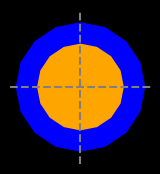

|111|
|001|
|001|


False

In [27]:
def inverted_overlaps_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    return circle6, circle4

a, b = inverted_overlaps_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

### Equals

<link rel="stylesheet" href="relations.css">
<table><tr><td>
<table  style="border: none;">
<tr class="l"  style="border: none;">
<th style="border: none;">Equals</th>
<th width=100 rowspan=2 style="border: none;">
<img src="../../Images/Relationships/equals.png" alt="Equals">
</th></tr>
<tr style="border: none;"><td class="d" style="border: none;">
The interiors of <span class="a">a</span> and <span class="b">b</span> 
intersect and no part of the interior of one geometry intersects the exterior of the other.
</td></tr></table>
</td><td>
<table class="f">
<tr><th>Matrix</th>
<td><table class="matrix">        
    <tr><td>T</td><td>*</td><td>F</td></tr>
    <tr><td>F</td><td>T</td><td>*</td></tr>
    <tr><td>*</td><td>*</td><td>*</td></tr>
    </table>
    </td>
</tr>
</tr><tr class="bin">
<th>Mask</th><td><span>101110000</span></td></tr>
<tr class="bin">
<th>Value</th><td><span>100010000</span></td></tr>
</table>
</tr></tr></table>

In [28]:
mask =  0b101110000
value = 0b100010000


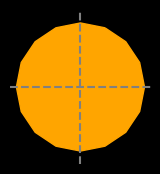

|100|
|010|
|001|


False

In [34]:
def equals_example():
    circle6 = shapely.Polygon(circle_points(3))
    return circle6, circle6

a, b = equals_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

### Contains

<link rel="stylesheet" href="relations.css">
<table><tr><td>
<table  style="border: none;">
<tr class="l"  style="border: none;">
<th style="border: none;">Contains</th>
<th width=100 rowspan=2 style="border: none;">
<img src="../../Images/Relationships/contains simple.png" alt="Contains">
</th></tr>
<tr style="border: none;"><td class="d" style="border: none;">
All points of <span class="b">b</span> lie in the interior of <span class="a">a</span>, no points of <span class="b">b</span> lie in the exterior of <span class="a">a</span>, some points in <span class="a">a</span> are exterior to <span class="b">b</span>, and the boundaries of <span class="a">a</span> and <span class="b">b</span> do not intersect.
</td></tr></table>
</td><td>
<table class="f">
<tr><th>Matrix</th>
<td><table class="matrix">        
    <tr><td>2</td><td>*</td><td>*</td></tr>
    <tr><td>F</td><td>F</td><td>*</td></tr>
    <tr><td>*</td><td>*</td><td>*</td></tr>
    </table>
    </td>
</tr>
</tr><tr class="bin">
<th>Mask</th><td><span>100110000</span></td></tr>
<tr class="bin">
<th>Value</th><td><span>100000000</span></td></tr>
</table>
</tr></tr></table>

In [31]:
mask =  0b100110000
value = 0b100000000


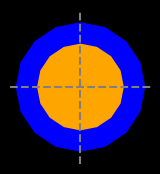

|111|
|001|
|001|


True

In [35]:
def simple_contains_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    return circle6, circle4

a, b = simple_contains_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

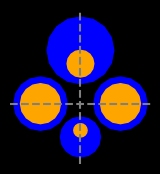

|111|
|001|
|001|


True

In [36]:
def multiple_contains_example():
    circle4_left = shapely.Polygon(circle_points(2, offset_x=-3))
    circle4_right = shapely.Polygon(circle_points(2, offset_x=3))
    circle3_left = shapely.Polygon(circle_points(1.5, offset_x=-3))
    circle3_right = shapely.Polygon(circle_points(1.5, offset_x=3))
    circle5_up = shapely.Polygon(circle_points(2.5, offset_y=4))
    circle2_up = shapely.Polygon(circle_points(1, offset_y=3))
    circle3_down = shapely.Polygon(circle_points(1.5, offset_y=-2.5))
    circle1_down = shapely.Polygon(circle_points(0.5, offset_y=-2))
    a = shapely.union_all([circle4_left, circle4_right, circle5_up, circle3_down])
    b = shapely.union_all([circle3_left, circle3_right, circle2_up, circle1_down])
    return a, b

a, b = multiple_contains_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

### Partition

<link rel="stylesheet" href="relations.css">
<table><tr><td>
<table  style="border: none;">
<tr class="l"  style="border: none;">
<th style="border: none;">Partition</th>
<th width=100 rowspan=2 style="border: none;">
<img src="../../Images/Relationships/partitions simple.png" alt="Partition">
</th></tr>
<tr style="border: none;"><td class="d" style="border: none;">
The boundaries of <span class="a">a</span> and <span class="b">b</span> have more than one point in common.
No points of <span class="b">b</span> are exterior to <span class="a">a</span>, and some points in <span class="a">a</span> are exterior to <span class="b">b</span>.
</td></tr></table>
</td><td>
<table class="f">
<tr><th>Matrix</th>
<td><table class="matrix">        
    <tr><td>T</td><td>*</td><td>T</td></tr>
    <tr><td>F</td><td>T</td><td>*</td></tr>
    <tr><td>*</td><td>*</td><td>*</td></tr>
    </table>
    </td>
</tr>
</tr><tr class="bin">
<th>Mask</th><td><span>101110000</span></td></tr>
<tr class="bin">
<th>Value</th><td><span>101010000</span></td></tr>
</table>
</tr></tr></table>

In [37]:
mask =  0b101110000
value = 0b101010000


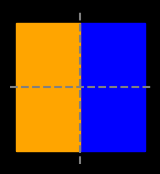

|111|
|011|
|001|


True

In [38]:
def simple_partition_example():
    box6 = poly_round(shapely.Polygon(box_points(4)))
    box4_offset = shapely.Polygon(box_points(height=4, width=2, offset_x=-1))
    return box6, box4_offset

a, b = simple_partition_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

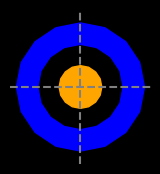

|101|
|011|
|001|


True

In [39]:
def partition_island_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle2 = shapely.Polygon(circle_points(1))
    a =(circle6 - circle4).union(circle2)
    return a, circle2

a, b = partition_island_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
r.test_relation(mask, value)

## Adjusting Boundary Slice Relations

For the beginning and ending slices of a structure the entire contour must
be treated as a boundary.  The structure does not have an interior on these
slices. In this case the “*Interior*” relations become “*Boundary*” relations.

The “*Interior*” bits of the DE-9IM relationship metric are combined with the 
“*Boundary*” bits using "OR" logic.  This will keep the “*Boundary*” bits as 
part of the boundary.



The `boundary_adjustment` method of the `DE9IM` class converts *interior* relations to *boundary* relations.

The `boundary_type` argument of the method takes one of two options:
<link rel="stylesheet" href="relations.css">
<table>
<tr><td><B><I>'a'</B></I></td>
<td>The <span class="a">a</span> polygon is from a boundary slice</td>
<td><img src="../../Images/Boundaries/a interior to boundary.png" /></td>
</tr><tr>
<td><B><I>'b'</B></I></td>
<td>The <span class="b">b</span> polygon is from a boundary slice</td>
<td><img src="../../Images/Boundaries/b interior to boundary.png" /></td>
</tr><tr>
</table>


In [40]:
def merge(relations: List[DE9IM]):
    num = 0
    for relation in relations:
        num = num | relation.to_int()
    num_str = to_str(num, size=9)
    matrix = DE9IM(relation_str=num_str)
    return matrix


### Boundary Adjustment Tests

#### Simple Contains

In [41]:
def simple_contains_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    return circle6, circle4


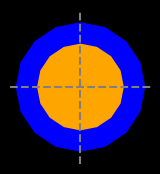

|111|
|001|
|001|
Adjusted Relation for "a" boundary
|000|
|100|
|000|
Adjusted Relation for "b" boundary
|010|
|000|
|000|
Adjusted Relation for combined boundaries
|000|
|010|
|000|


In [43]:
a, b = simple_contains_example()
ax = plot_ab(a, b)


r = DE9IM(a, b)
print(r)
print('Adjusted Relation for "a" boundary')
ra = r.boundary_adjustment('a')
print(ra)
print('Adjusted Relation for "b" boundary')
rb = r.boundary_adjustment('b')
print(rb)
print('Adjusted Relation for combined boundaries')
rc = r.boundary_adjustment('both')
print(rc)


In [44]:
# this should produce a partitions relation
r3D = merge([r, rc])
print(r3D)

mask =  0b101110000
value = 0b101010000
r3D.test_relation(mask, value)

|111|
|011|
|001|


True

#### Equals

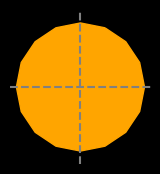

|100|
|010|
|001|
Adjusted Relation for "a" boundary
|000|
|100|
|000|
Adjusted Relation for "b" boundary
|010|
|000|
|000|
Adjusted Relation for combined boundaries
|000|
|010|
|000|


In [45]:
def equals_example():
    circle6 = shapely.Polygon(circle_points(3))
    return circle6, circle6

a, b = equals_example()
ax = plot_ab(a, b)
r = DE9IM(a, b)
print(r)
print('Adjusted Relation for "a" boundary')
ra = r.boundary_adjustment('a')
print(ra)
print('Adjusted Relation for "b" boundary')
rb = r.boundary_adjustment('b')
print(rb)
print('Adjusted Relation for combined boundaries')
rc = r.boundary_adjustment('both')
print(rc)


In [46]:
# This should maintain an equals relation
r3D = merge([r, rc])
print(r3D)

mask =  0b101110000
value = 0b100010000
r3D.test_relation(mask, value)

|100|
|010|
|001|


True

## Correcting for Holes

In some cases a relation may be generated for a polygon that is represents a hole (void) in a larger polygon. 
In this case the “*Interior*” relations become “*Exterior*” relations and the “*Exterior*” relations become “*Interior*” relations.

The “*Interior*” bits of the DE-9IM relationship metric are swapped with the “*Exterior*”.




The `hole_adjustment` method of the `DE9IM` class converts *interior* relations to *exterior* relations.

The `hole` argument of the method takes one of two options:
<link rel="stylesheet" href="relations.css">
<table>
<tr><td><B><I>'a'</B></I></td>
<td>The <span class="a">a</span> polygon is from a hole in another polygon</td>
<td><img src="../../Images/Boundaries/Correction for A as Hole.png" /></td>
</tr><tr>
<td><B><I>'b'</B></I></td>
<td>The <span class="b">b</span> polygon is from a hole in another polygon</td>
<td><img src="../../Images/Boundaries/Correction for B as Hole.png" /></td>
</tr><tr>
</table>


- 6 cm circle with 4 cm concentric hole
- 3 cm circle

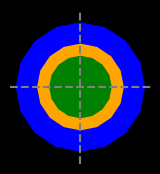

|111|
|101|
|101|


True

In [51]:
def overlaps_cylinder_with_hole():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle3 = shapely.Polygon(circle_points(1.5))
    a = circle6 - circle3
    return a, circle4

a, b = overlaps_cylinder_with_hole()
plot_ab(a, b)
# Compare the exterior of a with b
r = DE9IM(a, b)
print(r)

# Overlaps Test
mask =  0b100100000
value = 0b100100000
r.test_relation(mask, value)

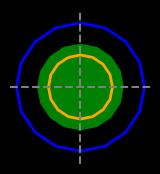

|101|
|000|
|111|
False
True


In [66]:
a, b = overlaps_cylinder_with_hole()
plot_ab(a.boundary, b)
# Compare the exterior of a with b
re = DE9IM(relation_str=a.boundary.relate(b))
print(re)

# Overlaps Test
mask =  0b100100000
value = 0b100100000
print(re.test_relation(mask, value))

# Contains Test
mask =  0b100110000
value = 0b100000000
print(re.test_relation(mask, value))

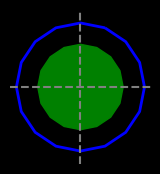

|001|
|000|
|111|
False
False


In [67]:
a, b = overlaps_cylinder_with_hole()
plot_ab(a.exterior, b)
# Compare the exterior of a with b
re = DE9IM(relation_str=a.exterior.relate(b))
print(re)

# Overlaps Test
mask =  0b100100000
value = 0b100100000
print(re.test_relation(mask, value))

# Contains Test
mask =  0b100110000
value = 0b100000000
print(re.test_relation(mask, value))

In [69]:
hole = shapely.Polygon(a.interiors[0])
rah = DE9IM(hole, b)
rh = rah.hole_adjustment('a')
rhb = rh.boundary_adjustment('a')
print(rah)
print('adjusted for hole in "a"')
print(rh)
print('adjusted for hole boundary in a')
print(rhb)


|100|
|100|
|111|
adjusted for hole in "a"
|000|
|100|
|100|
adjusted for hole boundary in a
|000|
|000|
|000|


In [70]:
rc = rhb.merge([re])
print(rc)

|001|
|000|
|111|


In [71]:
# Overlaps Test
mask =  0b100100000
value = 0b100100000
rc.test_relation(mask, value)

False

In [67]:
def overlaps_archipelago_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle2 = shapely.Polygon(circle_points(1))

    a = StructureSlice([circle6, circle4, circle2])
    b = StructureSlice([circle4])
    return a, b

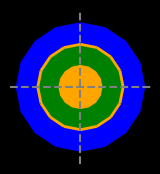

|101|
|111|
|101|


In [68]:
a, b = overlaps_archipelago_example()
plot_ab(a.contour, b.contour)
# Compare the exterior of a with b
r = DE9IM(a.contour, b.contour)
print(r)


In [69]:
# Overlaps Test
mask =  0b100100000
value = 0b100100000
rc.test_relation(mask, value)

True

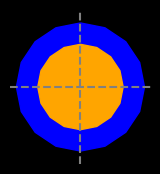

|111|
|001|
|001|


In [ ]:
plot_ab(a.exterior, b.contour)
# Compare the exterior of a with b
r0 = DE9IM(a.exterior, b.contour)
print(r0)


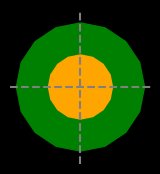

|100|
|100|
|111|


In [ ]:
island = shapely.Polygon(a.contour.geoms[1])
plot_ab(island, b.contour)
# Compare the exterior of a with b
r2 = DE9IM(island, b.contour)
print(r2)


In [72]:
hole = shapely.Polygon(a.contour.geoms[0].interiors[0])
rah = DE9IM(hole, b.contour)
rh = rah.hole_adjustment('a')
rhb = rh.boundary_adjustment('a')
print(rah)
print('adjusted for hole in "a"')
print(rh)


|100|
|010|
|001|
adjusted for hole in "a"
|000|
|010|
|100|


In [73]:
rc = rh.merge([r0, r2])
print(rc)

|111|
|111|
|111|


In [74]:
# Overlaps Test
mask =  0b100100000
value = 0b100100000
rc.test_relation(mask, value)

True

## Secondary Boundary Tests (Transpose Method)
- Regions that are only boundaries of the Secondary ROI also need to be 
  identified and tested in the same way as the Primary ROI.

- It may be easier to implement by reversing the Primary and Secondary ROI and 
then transposing the matrix. 
> `shapely.relate(poly_a, poly_b)` $\equiv$ `shapely.relate(poly_a, poly_b).T`


### Contains

In [75]:
mask =  0b100110000
value = 0b100000000


In [76]:
def simple_contains_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    a = StructureSlice([circle6])
    b = StructureSlice([circle4])
    return a, b


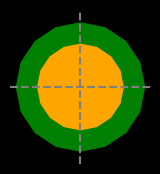

|100|
|100|
|111|
Contains Test:	 False
Transposed Matrix
|111|
|001|
|001|
Contains Test on Transposed Matrix:	 True


In [77]:
a, b = simple_contains_example()
# Reverse the polygons
ax = plot_ab(b.contour, a.contour)

rr = DE9IM(b.contour, a.contour)
print(rr)
print('Contains Test:\t', rr.test_relation(mask, value))
print('Transposed Matrix')
rt = rr.transpose()
print(rt)
print('Contains Test on Transposed Matrix:\t', rt.test_relation(mask, value))


### Overlaps (non-symmetric case)

In [78]:
mask =  0b100100000
value = 0b100100000


In [79]:
def overlaps_island_example():
    circle6 = shapely.Polygon(circle_points(3))
    circle4 = shapely.Polygon(circle_points(2))
    circle2 = shapely.Polygon(circle_points(1))
    circle3 = shapely.Polygon(circle_points(1.5))

    a = StructureSlice([circle6, circle4, circle2])
    b = StructureSlice([circle3])
    return a, b


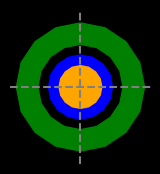

|111|
|001|
|111|
Overlaps Test:	 False
Transposed Matrix
|101|
|101|
|111|
Overlaps Test on Transposed Matrix:	 True


In [80]:
a, b = overlaps_island_example()
# Reverse the polygons
ax = plot_ab(b.contour, a.contour)

rr = DE9IM(b.contour, a.contour)
print(rr)
print('Overlaps Test:\t', rr.test_relation(mask, value))
print('Transposed Matrix')
rt = rr.transpose()
print(rt)
print('Overlaps Test on Transposed Matrix:\t', rt.test_relation(mask, value))

### Exterior Borders (Symmetric)

In [81]:
mask =  0b100010000
value = 0b000010000


In [82]:
def simple_box_borders_example():
    box4_left = shapely.Polygon(box_points(4, offset_x=-2))
    box4_right = shapely.Polygon(box_points(4, offset_x=2))

    a = StructureSlice([box4_left])
    b = StructureSlice([box4_right])
    return a, b


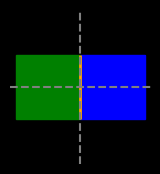

|001|
|011|
|111|
Borders Test:	 True
Transposed Matrix
|001|
|011|
|111|
Borders Test on Transposed Matrix:	 True


In [83]:
a, b = simple_box_borders_example()
# Reverse the polygons
ax = plot_ab(b.contour, a.contour)

rr = DE9IM(b.contour, a.contour)
print(rr)
print('Borders Test:\t', rr.test_relation(mask, value))
print('Transposed Matrix')
rt = rr.transpose()
print(rt)
print('Borders Test on Transposed Matrix:\t', rt.test_relation(mask, value))

### Equals (Symmetric)

In [84]:
mask =  0b101110000
value = 0b100010000


In [85]:
def equals_example():
    circle6 = shapely.Polygon(circle_points(3))
    a = StructureSlice([circle6])
    return a, a


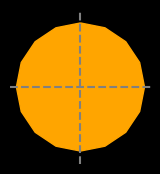

|100|
|010|
|001|
Equals Test:	 True
Transposed Matrix
|100|
|010|
|001|
Equals Test on Transposed Matrix:	 True


In [86]:
a, b = equals_example()
# Reverse the polygons
ax = plot_ab(b.contour, a.contour)

rr = DE9IM(b.contour, a.contour)
print(rr)
print('Equals Test:\t', rr.test_relation(mask, value))
print('Transposed Matrix')
rt = rr.transpose()
print(rt)
print('Equals Test on Transposed Matrix:\t', rt.test_relation(mask, value))